# London air quality analysis

* Author: Andrew Sivanesan
* Date: 1st Feb 2026

## Executive summary

TBC

## Background

TBC

In [19]:
import pandas as pd
from pyproj import CRS, Transformer
import seaborn as sns
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap

## Data preparation

In [2]:
# Initialise a transformer that converts eastings and northings from the British National Grid coordinate reference system (CRS) to latitudes and longitudes in the WGS 1984 ellipsoid CRS
transformer = Transformer.from_crs("EPSG:27700", "EPSG:4326")

In [59]:
# define the name of the file to be read into the Pandas DataFrame
fname = "EmissionsByGridID_2022to2030.csv"

# read in the file
df = pd.read_csv(fname)

# create latitude and longitude columns
df["Latitude"] = df.apply(lambda x: transformer.transform(x["easting"], x["northing"])[0], axis=1)
df["Longitude"] = df.apply(lambda x: transformer.transform(x["easting"], x["northing"])[1], axis=1)

# define the filter conditions
cond_kingston_petrol_cars = (df["Year"] == 2022) & (df["Borough"] == "Kingston") & (df["Source"] == ("Car - Petrol"))
#cond_kingston_diesel_cars = (df["Year"] == 2022) & (df["Borough"] == "Kingston") & (df["Source"] == ("Car - Diesel"))

# define the columns to select
cols = ["LAEI 1km2 ID", "Latitude", "Longitude", "pm2.5"]

# apply filters and select columns
petrol_cars = df[cond_kingston_petrol_cars][cols]
#diesel_cars = df[cond_kingston_diesel_cars][cols]

## Exploratory data analysis

* There are **59 rows** of Kingston petrol cars data.
* All columns are fully populated i.e. there are **no missing values.**
* The pm2.5 column is **right-skewed**

In [60]:
petrol_cars.describe()

,LAEI 1km2 ID,Latitude,Longitude,pm2.5
count,59.000000,59.000000,59.000000,59.000000
mean,12236.118644,51.387458,-0.287401,0.174073
std,593.963951,0.030903,0.025799,0.168288
min,11252.000000,51.322682,-0.329473,0.000000
25%,11767.500000,51.366893,-0.311663,0.046236
50%,12114.000000,51.393323,-0.285099,0.133251
75%,12627.500000,51.411832,-0.268542,0.234304
max,13484.000000,51.438688,-0.239967,0.666482


In [61]:
petrol_cars.isnull().sum()

LAEI 1km2 ID    0
Latitude        0
Longitude       0
pm2.5           0
dtype: int64

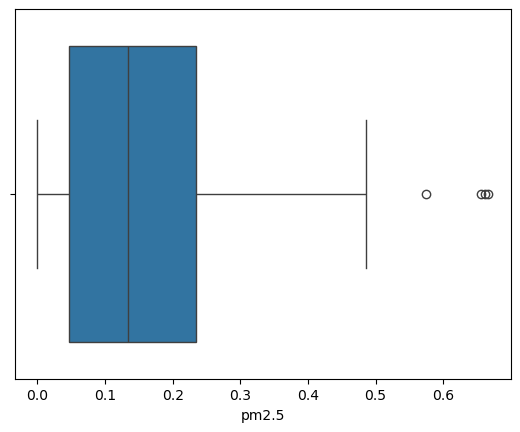

In [62]:
sns.boxplot(x=petrol_cars["pm2.5"])
plt.show()

In [74]:
# Apply Tukey's fence to filter for outlier values

LQ = petrol_cars["pm2.5"].quantile(0.25)
UQ = petrol_cars["pm2.5"].quantile(0.75)
IQR = UQ - LQ
tukey_fence_upper = UQ + (1.5 * IQR)
cond_tukey_fence_upper = petrol_cars["pm2.5"] > tukey_fence_upper

outliers = petrol_cars[cond_tukey_fence_upper].reset_index()
outliers

,index,LAEI 1km2 ID,Latitude,Longitude,pm2.5
0,416947,12113.0,51.393537,-0.255023,0.661589
1,416968,12454.0,51.376196,-0.298789,0.656297
2,417429,11766.0,51.412147,-0.297456,0.573877
3,417483,12455.0,51.375986,-0.284428,0.666482


FixMe(20260207)

* Add GeoJSON boundary file for Royal Borough of Kingston
* Consider more impactful way of visualising the locations of outlier pm2.5 values

https://realpython.com/python-folium-web-maps-from-data/
https://geoportal.statistics.gov.uk/search?q=london%20boroughs&sort=Date%20Created%7Ccreated%7Cdesc

In [85]:
# Plot heatmap weighted by pm2.5 column

kingston_coords = [51.4123, -0.3007]
m1 = folium.Map(location=kingston_coords, zoom_start=12)


for i in range(len(outliers)):
    folium.Marker(
        location=[outliers["Latitude"][i], outliers["Longitude"][i]],
        tooltip=str(round(outliers["pm2.5"][i], 2)) + " of pm2.5 tonnes per annum"
    ).add_to(m1)

#HeatMap(outliers[["Latitude", "Longitude", "pm2.5"]]).add_to(m1)
m1

In [49]:
# Plot heatmap weighted by pm2.5 column
m2 = folium.Map(location=kingston_coords, zoom_start=12)
cond_petrol = cars["Source"].str.contains("Petrol")
petrol_cars = cars[cond_petrol]

HeatMap(petrol_cars[["Latitude", "Longitude", "pm2.5"]]).add_to(m2)
m2